In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os
import torch
import seaborn as sns
import copy
from scipy.stats import pearsonr, ttest_ind

In [2]:
import sys
sys.path.append('../code/BalancingControl')
import tmaze_utils as tu
import inference_utils as iu
import inference as inf

import misc

Running on device cpu
torch threads 1


In [3]:
groups = ["control", "cie"]

agents = ["BCC_2pars_planning_repetition_weight"]

In [4]:
results_dir = os.path.abspath('results')
inference_folder = os.path.join(results_dir, "inference")
print(inference_folder)

/home/sarah/src/TMaze/cie_task/results/inference


In [5]:
results = {}
data = {}
n_agents = {}
num_steps = 600

for grp in groups:
    base_dir = "processed_data"
    fname_data = os.path.join(base_dir, f"TMaze_{grp}_structured_data.json")
    structured_data = misc.load_file(fname_data, fname_data)
    data[grp] = structured_data
    n_agents[grp] = len(structured_data["subject"][0])
    for agt in agents:
        fname_base = agt+"_"+grp+"_inference_"
        fname_str = fname_base + str(num_steps)+'_'+str(n_agents[grp])+'agents'
        # define folder where we want to save data
        base_dir = os.path.join(inference_folder,fname_base[:-1])
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 
        print(f"{agt}_{grp}")
        results[f"{agt}_{grp}"] = {}
        results[f"{agt}_{grp}"]["mean_df"] = mean_df
        results[f"{agt}_{grp}"]["sample_df"] = sample_df
        results[f"{agt}_{grp}"]["locs_df"] = locs_df

BCC_2pars_planning_repetition_weight_control
BCC_2pars_planning_repetition_weight_cie


In [6]:
base_dir = "processed_data"
fname_plot_df = os.path.join(base_dir, "plot_df.csv")
plot_df = pd.read_csv(fname_plot_df)

In [7]:
plot_df["correct"][plot_df["trial_type"]=="early test"]

75      0.0
76      0.0
77      1.0
78      0.0
79      0.0
       ... 
2315    0.0
2316    0.0
2317    0.0
2318    1.0
2319    1.0
Name: correct, Length: 75, dtype: float64

In [8]:
plot_df[plot_df["trial_type"]=="early test"].groupby(["animal", "group"])["correct"].mean()

animal  group  
20.0    cie        0.4
24.0    control    0.2
25.0    control    0.2
26.0    control    0.2
27.0    control    0.4
32.0    control    0.4
33.0    control    0.0
34.0    control    0.2
35.0    control    0.2
38.0    cie        0.6
39.0    cie        0.4
44.0    cie        0.2
45.0    cie        0.2
46.0    cie        1.0
47.0    cie        0.6
Name: correct, dtype: float64

In [9]:
plot_df[plot_df["trial_type"]=="late test"].groupby(["animal", "group"])["correct"].mean()

animal  group  
20.0    cie        0.4
24.0    control    0.4
25.0    control    0.4
26.0    control    0.2
27.0    control    0.8
32.0    control    0.6
33.0    control    0.2
34.0    control    0.8
35.0    control    0.6
38.0    cie        0.8
39.0    cie        0.4
44.0    cie        0.6
45.0    cie        1.0
46.0    cie        0.2
47.0    cie        0.8
Name: correct, dtype: float64

In [10]:
print(results.keys())
results[agents[0]+"_cie"]

dict_keys(['BCC_2pars_planning_repetition_weight_control', 'BCC_2pars_planning_repetition_weight_cie'])


{'mean_df':    Unnamed: 0  inferred dec temp  subject  inferred habitual tendency
 0           0           1.188513        0                    5.084594
 1           1           0.742928        1                    1.890698
 2           2           1.149956        2                    1.595498
 3           3           0.397710        3                    1.414291
 4           4           0.821317        4                    1.902323
 5           5           0.401914        5                    2.425664
 6           6           1.394156        6                    1.849060,
 'sample_df':       Unnamed: 0  dec temp  habitual tendency  subject
 0              0  1.157892           4.627977        0
 1              1  0.771543           1.260934        1
 2              2  0.932722           2.250808        2
 3              3  0.422130           0.807225        3
 4              4  0.783925           1.424118        4
 ...          ...       ...                ...      ...
 3495        34

In [11]:
cie_early_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_late_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values

cie_dec_temp = results[agents[0]+"_cie"]["mean_df"]["inferred dec temp"]
cie_hab_tend = results[agents[0]+"_cie"]["mean_df"]["inferred habitual tendency"]

/tmp/ipykernel_14162/3176153628.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_early_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
/tmp/ipykernel_14162/3176153628.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_late_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values


In [12]:
cie_omega = cie_dec_temp / (cie_dec_temp + cie_hab_tend)

cie_beta = (cie_dec_temp + cie_hab_tend)

In [13]:
cie_dict = {"early acc": cie_early_accuracy, "late acc": cie_late_accuracy, 
            "dec temp": cie_dec_temp, "hab tend": cie_hab_tend,
            "omega": cie_omega, "beta": cie_beta}

cie_df = pd.DataFrame(cie_dict)

In [14]:
cie_df.corr()

,early acc,late acc,dec temp,hab tend,omega,beta
early acc,1.000000,-0.506061,-0.149338,0.073021,-0.251654,0.023739
late acc,-0.506061,1.000000,0.192340,-0.371875,0.451384,-0.276129
dec temp,-0.149338,0.192340,1.000000,0.298602,0.697800,0.537112
hab tend,0.073021,-0.371875,0.298602,1.000000,-0.467449,0.965411
omega,-0.251654,0.451384,0.697800,-0.467449,1.000000,-0.222510
beta,0.023739,-0.276129,0.537112,0.965411,-0.222510,1.000000


In [15]:
print("p val cie dec temp & hab tend")
print(pearsonr(cie_dec_temp, cie_hab_tend))

print("p val cie early acc & dec temp")
print(pearsonr(cie_early_accuracy, cie_dec_temp))

print("p val cie late acc & dec temp")
print(pearsonr(cie_late_accuracy, cie_dec_temp))

print("p val cie early acc & hab tend")
print(pearsonr(cie_early_accuracy, cie_hab_tend))

print("p val cie late acc & hab tend")
print(pearsonr(cie_late_accuracy, cie_hab_tend))

p val cie dec temp & hab tend
PearsonRResult(statistic=np.float64(0.2986022314285391), pvalue=np.float64(0.51537101354537))
p val cie early acc & dec temp
PearsonRResult(statistic=np.float64(-0.14933809342140678), pvalue=np.float64(0.7492933277007133))
p val cie late acc & dec temp
PearsonRResult(statistic=np.float64(0.19233951690975637), pvalue=np.float64(0.679480455403714))
p val cie early acc & hab tend
PearsonRResult(statistic=np.float64(0.07302089065955536), pvalue=np.float64(0.8763661128529531))
p val cie late acc & hab tend
PearsonRResult(statistic=np.float64(-0.37187464776901696), pvalue=np.float64(0.41141738063264655))


In [16]:
print("p val cie omega & beta")
print(pearsonr(cie_omega, cie_beta))

print("p val cie early acc & omega")
print(pearsonr(cie_early_accuracy, cie_omega))

print("p val cie late acc & omega")
print(pearsonr(cie_late_accuracy, cie_omega))

print("p val cie early acc & beta")
print(pearsonr(cie_early_accuracy, cie_beta))

print("p val cie late acc & beta")
print(pearsonr(cie_late_accuracy, cie_beta))

p val cie omega & beta
PearsonRResult(statistic=np.float64(-0.22250972530642435), pvalue=np.float64(0.6315370634263666))
p val cie early acc & omega
PearsonRResult(statistic=np.float64(-0.2516539033866664), pvalue=np.float64(0.5861774541752923))
p val cie late acc & omega
PearsonRResult(statistic=np.float64(0.45138439371189765), pvalue=np.float64(0.30932395653451))
p val cie early acc & beta
PearsonRResult(statistic=np.float64(0.023739497892139142), pvalue=np.float64(0.9597099319328709))
p val cie late acc & beta
PearsonRResult(statistic=np.float64(-0.2761285390249291), pvalue=np.float64(0.5488945018349872))


In [17]:
control_early_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_late_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values

control_dec_temp = results[agents[0]+"_control"]["mean_df"]["inferred dec temp"]
control_hab_tend = results[agents[0]+"_control"]["mean_df"]["inferred habitual tendency"]

/tmp/ipykernel_14162/3698181728.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_early_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
/tmp/ipykernel_14162/3698181728.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_late_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values


In [18]:
control_omega = control_dec_temp / (control_dec_temp + control_hab_tend)

control_beta = (control_dec_temp + control_hab_tend)

In [19]:
control_dict = {"early acc": control_early_accuracy, "late acc": control_late_accuracy, 
                "dec temp": control_dec_temp, "hab tend": control_hab_tend,
                "omega": control_omega, "beta": control_beta}

control_df = pd.DataFrame(control_dict)

In [20]:
control_df.corr()

,early acc,late acc,dec temp,hab tend,omega,beta
early acc,1.000000,0.652753,0.431977,-0.712435,0.652056,-0.382585
late acc,0.652753,1.000000,0.668159,-0.515503,0.819799,-0.069029
dec temp,0.431977,0.668159,1.000000,-0.130550,0.891066,0.468021
hab tend,-0.712435,-0.515503,-0.130550,1.000000,-0.557204,0.815054
omega,0.652056,0.819799,0.891066,-0.557204,1.000000,0.024064
beta,-0.382585,-0.069029,0.468021,0.815054,0.024064,1.000000


In [21]:
print("p val control dec temp & hab tend")
print(pearsonr(control_dec_temp, control_hab_tend))

print("p val control early acc & dec temp")
print(pearsonr(control_early_accuracy, control_dec_temp))

print("p val control late acc & dec temp")
print(pearsonr(control_late_accuracy, control_dec_temp))

print("p val control early acc & hab tend")
print(pearsonr(control_early_accuracy, control_hab_tend))

print("p val control late acc & hab tend")
print(pearsonr(control_late_accuracy, control_hab_tend))

p val control dec temp & hab tend
PearsonRResult(statistic=np.float64(-0.13054977268100326), pvalue=np.float64(0.7579861952195696))
p val control early acc & dec temp
PearsonRResult(statistic=np.float64(0.4319767126845278), pvalue=np.float64(0.28516362796381134))
p val control late acc & dec temp
PearsonRResult(statistic=np.float64(0.6681588575762183), pvalue=np.float64(0.07012720907121611))
p val control early acc & hab tend
PearsonRResult(statistic=np.float64(-0.7124352832229676), pvalue=np.float64(0.0473650758909433))
p val control late acc & hab tend
PearsonRResult(statistic=np.float64(-0.5155031758527076), pvalue=np.float64(0.19101934417549202))


In [22]:
print("p val control omega & beta")
print(pearsonr(control_omega, control_beta))

print("p val control early acc & omega")
print(pearsonr(control_early_accuracy, control_omega))

print("p val control late acc & omega")
print(pearsonr(control_late_accuracy, control_omega))

print("p val control early acc & beta")
print(pearsonr(control_early_accuracy, control_beta))

print("p val control late acc & beta")
print(pearsonr(control_late_accuracy, control_beta))

p val control omega & beta
PearsonRResult(statistic=np.float64(0.02406428094322524), pvalue=np.float64(0.954896889424319))
p val control early acc & omega
PearsonRResult(statistic=np.float64(0.6520561564510023), pvalue=np.float64(0.0797405354676646))
p val control late acc & omega
PearsonRResult(statistic=np.float64(0.8197988440263102), pvalue=np.float64(0.012723077846910735))
p val control early acc & beta
PearsonRResult(statistic=np.float64(-0.38258525315315134), pvalue=np.float64(0.3495783332624533))
p val control late acc & beta
PearsonRResult(statistic=np.float64(-0.06902917133320557), pvalue=np.float64(0.8709808732855372))


In [23]:
ttest_ind(control_early_accuracy, cie_early_accuracy)

TtestResult(statistic=np.float64(-2.3775949983830698), pvalue=np.float64(0.033457939542309974), df=np.float64(13.0))

In [24]:
ttest_ind(control_late_accuracy, cie_late_accuracy)

TtestResult(statistic=np.float64(-0.7426406610973785), pvalue=np.float64(0.4709064139869783), df=np.float64(13.0))

In [25]:
ttest_ind(control_dec_temp, cie_dec_temp)

TtestResult(statistic=np.float64(1.769346976404056), pvalue=np.float64(0.10027386556300316), df=np.float64(13.0))

In [26]:
ttest_ind(control_hab_tend, cie_hab_tend)

TtestResult(statistic=np.float64(0.7931074937731649), pvalue=np.float64(0.44195046141880245), df=np.float64(13.0))

In [27]:
print(np.append(control_early_accuracy, cie_early_accuracy).shape)

print(cie_early_accuracy.shape)

(15,)
(7,)


In [28]:
control_omega = control_dec_temp / (control_dec_temp + control_hab_tend)

control_beta = (control_dec_temp + control_hab_tend)

cie_omega = cie_dec_temp / (cie_dec_temp + cie_hab_tend)

cie_beta = (cie_dec_temp + cie_hab_tend)

In [29]:
ttest_ind(control_omega, cie_omega)

TtestResult(statistic=np.float64(0.8625912750988088), pvalue=np.float64(0.40399470774457424), df=np.float64(13.0))

In [30]:
ttest_ind(control_beta, cie_beta)

TtestResult(statistic=np.float64(1.5111274510383732), pvalue=np.float64(0.15467695226861997), df=np.float64(13.0))

In [31]:
group_comp_dict = {"group": ["control"]*n_agents["control"]+["cie"]*n_agents["cie"], "early acc": np.append(control_early_accuracy, cie_early_accuracy), 
                   "late acc": np.append(control_late_accuracy, cie_late_accuracy), "dec temp": np.append(control_dec_temp, cie_dec_temp), "hab tend": np.append(control_hab_tend,cie_hab_tend),
                   "omega": np.append(control_omega, cie_omega), "beta": np.append(control_beta, cie_beta)}

group_comp_df = pd.DataFrame(group_comp_dict)

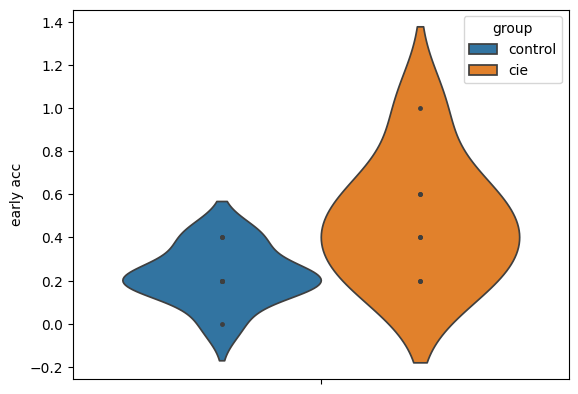

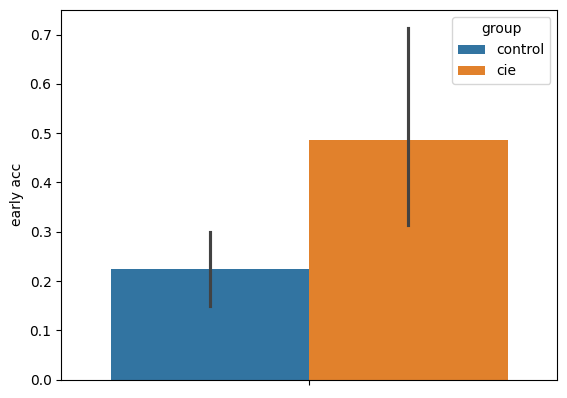

In [32]:
plt.figure()
sns.violinplot(data=group_comp_df, y="early acc", hue="group", inner="point")
plt.show()

plt.figure()
sns.barplot(data=group_comp_df, y="early acc", hue="group")
plt.show()

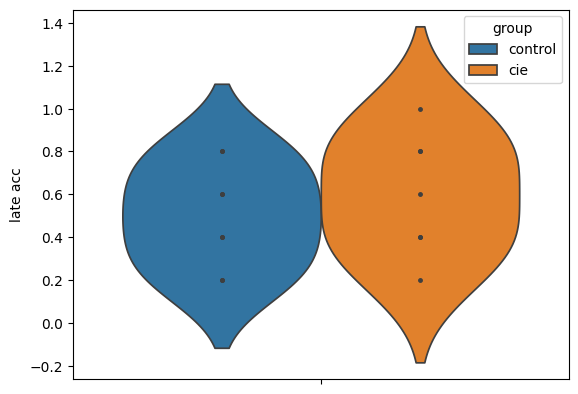

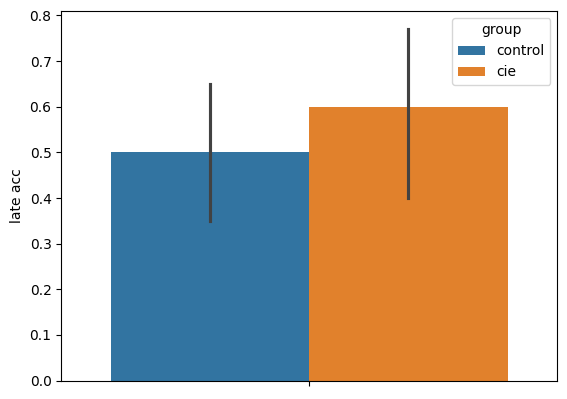

In [33]:
plt.figure()
sns.violinplot(data=group_comp_df, y="late acc", hue="group", inner="point")
plt.show()

plt.figure()
sns.barplot(data=group_comp_df, y="late acc", hue="group")
plt.show()

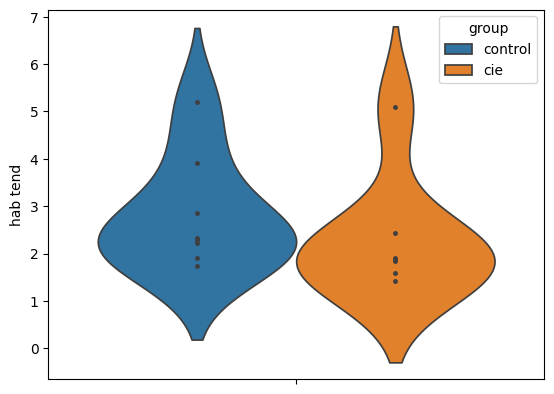

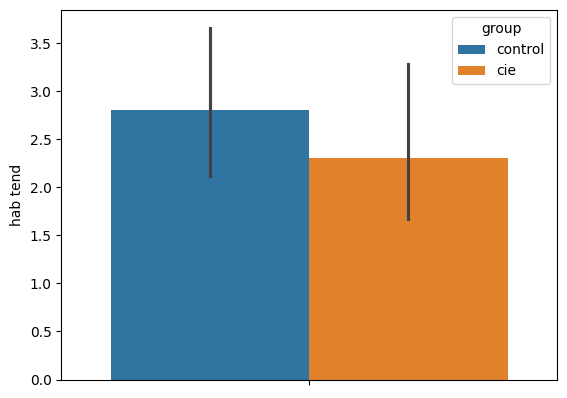

In [34]:
plt.figure()
sns.violinplot(data=group_comp_df, y="hab tend", hue="group", inner="point")
plt.show()

plt.figure()
sns.barplot(data=group_comp_df, y="hab tend", hue="group")
plt.show()

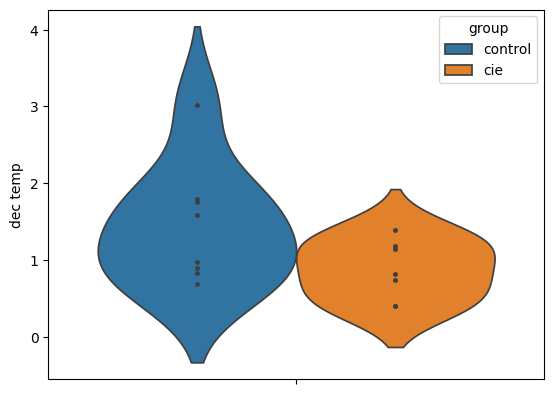

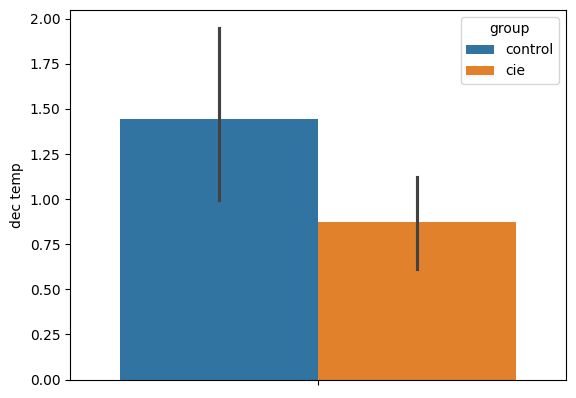

In [35]:
plt.figure()
sns.violinplot(data=group_comp_df, y="dec temp", hue="group", inner="point")
plt.show()

plt.figure()
sns.barplot(data=group_comp_df, y="dec temp", hue="group")
plt.show()

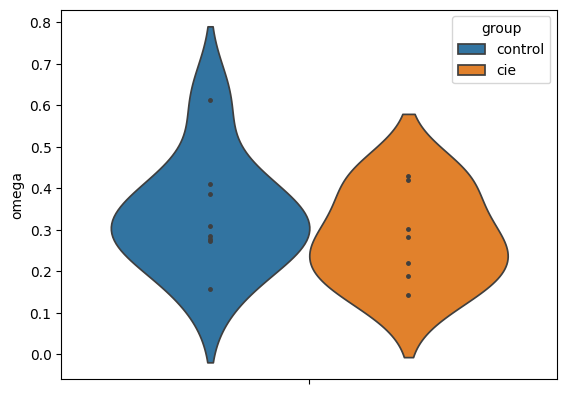

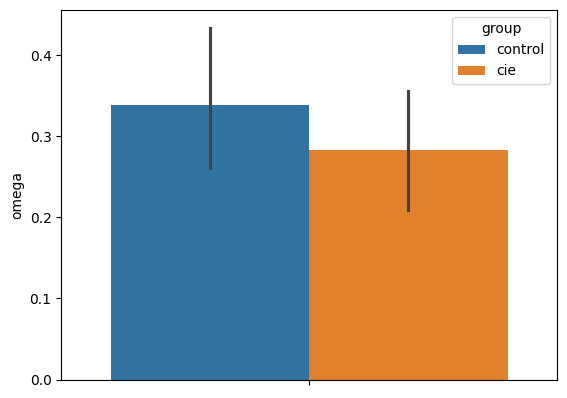

In [36]:
plt.figure()
sns.violinplot(data=group_comp_df, y="omega", hue="group", inner="point")
plt.show()

plt.figure()
sns.barplot(data=group_comp_df, y="omega", hue="group")
plt.show()

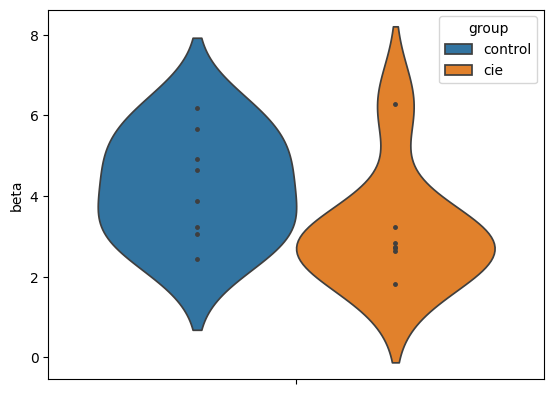

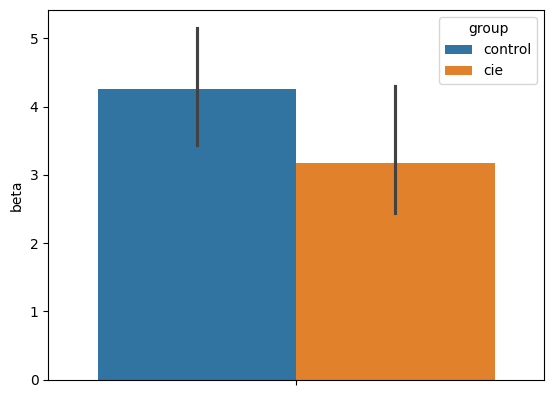

In [37]:
plt.figure()
sns.violinplot(data=group_comp_df, y="beta", hue="group", inner="point")
plt.show()

plt.figure()
sns.barplot(data=group_comp_df, y="beta", hue="group")
plt.show()

<Figure size 640x480 with 0 Axes>

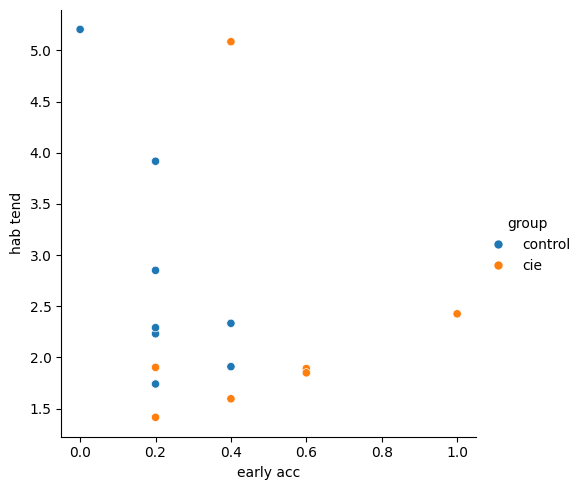

<Figure size 640x480 with 0 Axes>

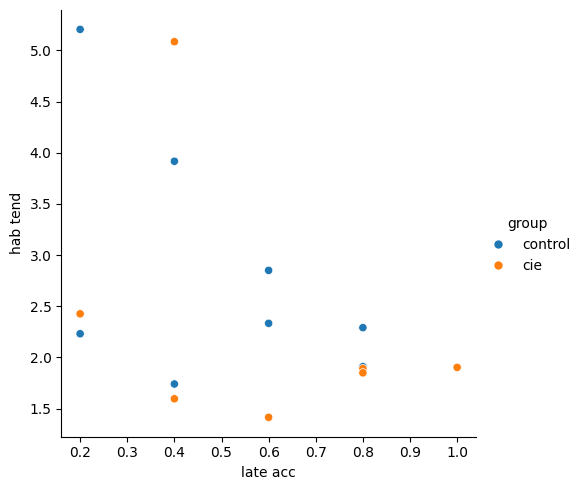

In [38]:
plt.figure()
sns.relplot(data=group_comp_df, y="hab tend", x="early acc", hue="group")
plt.show()

plt.figure()
sns.relplot(data=group_comp_df, y="hab tend", x="late acc", hue="group")
plt.show()

<Figure size 640x480 with 0 Axes>

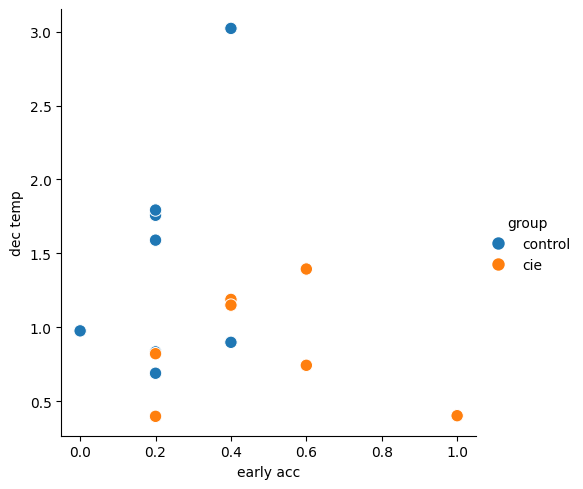

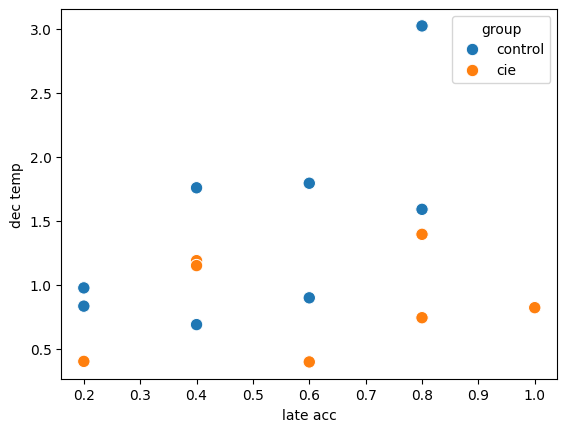

In [39]:
plt.figure()
sns.relplot(data=group_comp_df, y="dec temp", x="early acc", hue="group", marker="o", s=80)
plt.show()

plt.figure()
sns.scatterplot(data=group_comp_df, y="dec temp", x="late acc", hue="group", marker="o", s=80)#sizes=(200,200))
plt.show()

<Figure size 640x480 with 0 Axes>

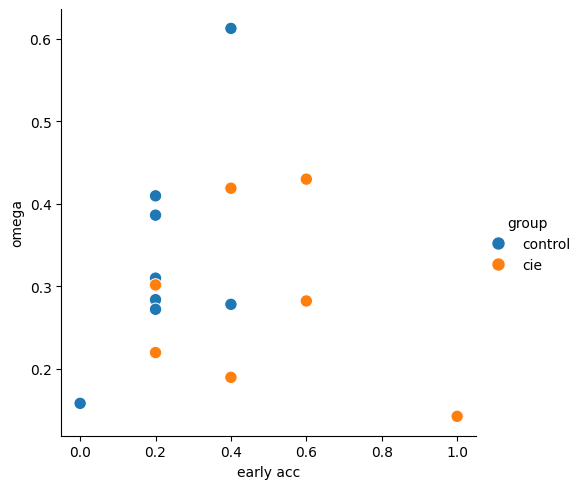

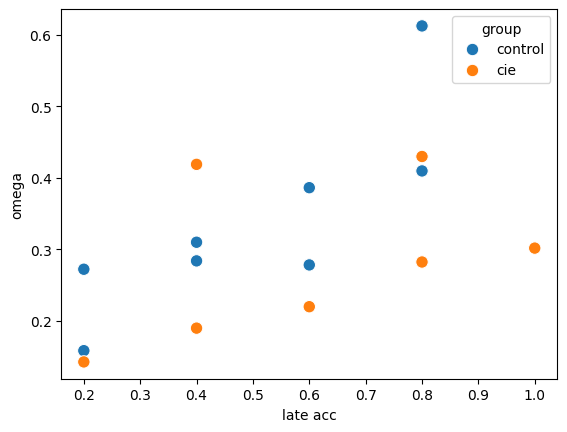

In [40]:
plt.figure()
sns.relplot(data=group_comp_df, y="omega", x="early acc", hue="group", marker="o", s=80)
plt.show()

plt.figure()
sns.scatterplot(data=group_comp_df, y="omega", x="late acc", hue="group", marker="o", s=80)#sizes=(200,200))
plt.show()

<Figure size 640x480 with 0 Axes>

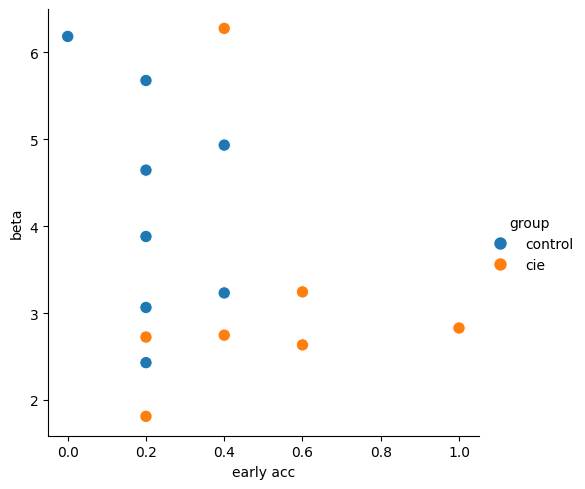

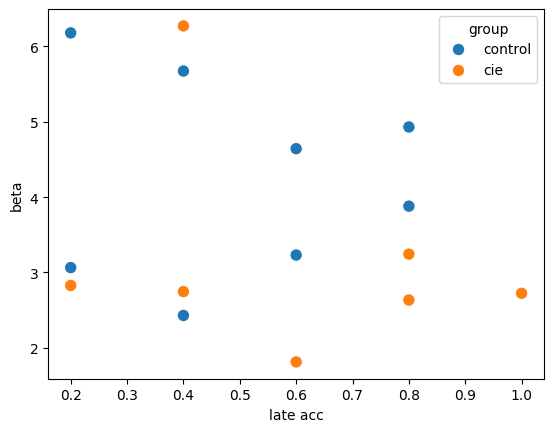

In [41]:
plt.figure()
sns.relplot(data=group_comp_df, y="beta", x="early acc", hue="group", marker="o", s=80)
plt.show()

plt.figure()
sns.scatterplot(data=group_comp_df, y="beta", x="late acc", hue="group", marker="o", s=80)#sizes=(200,200))
plt.show()